# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

---

## K-means Run

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    # NUV-r
    # W1-W3

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

#####################################################
Removed 4566/6780 galaxies with GALFIT quality flags.
#####################################################
IQR clipping (k=1.5): Removing an additional 678/2214 outliers (30.6%)
Remaining galaxies: 1536


A copy of the scaled galaxy features was written to data/feature_data.csv!

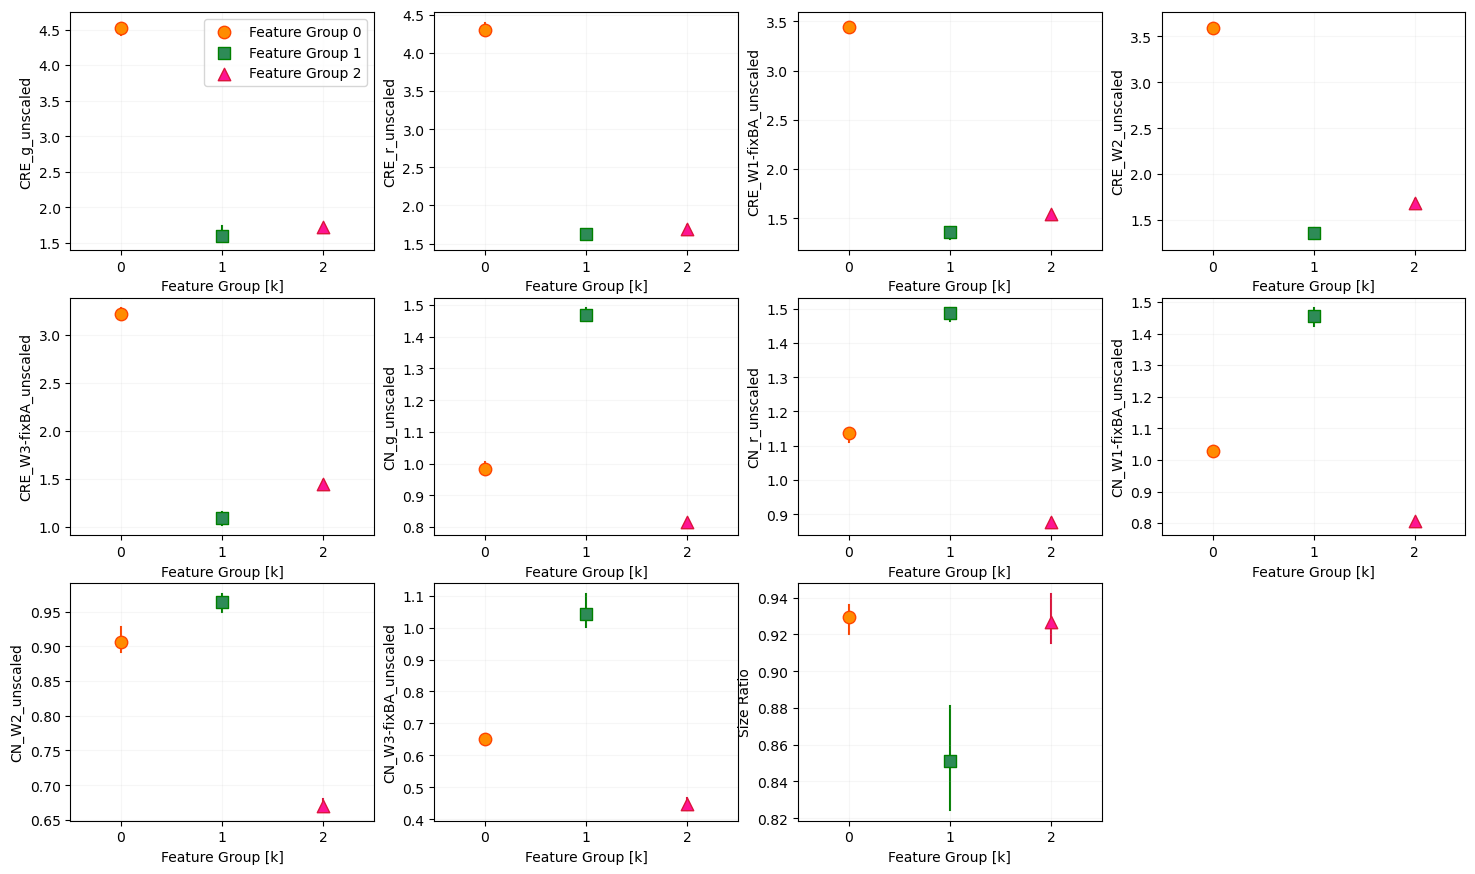

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/kmeans_features.csv:

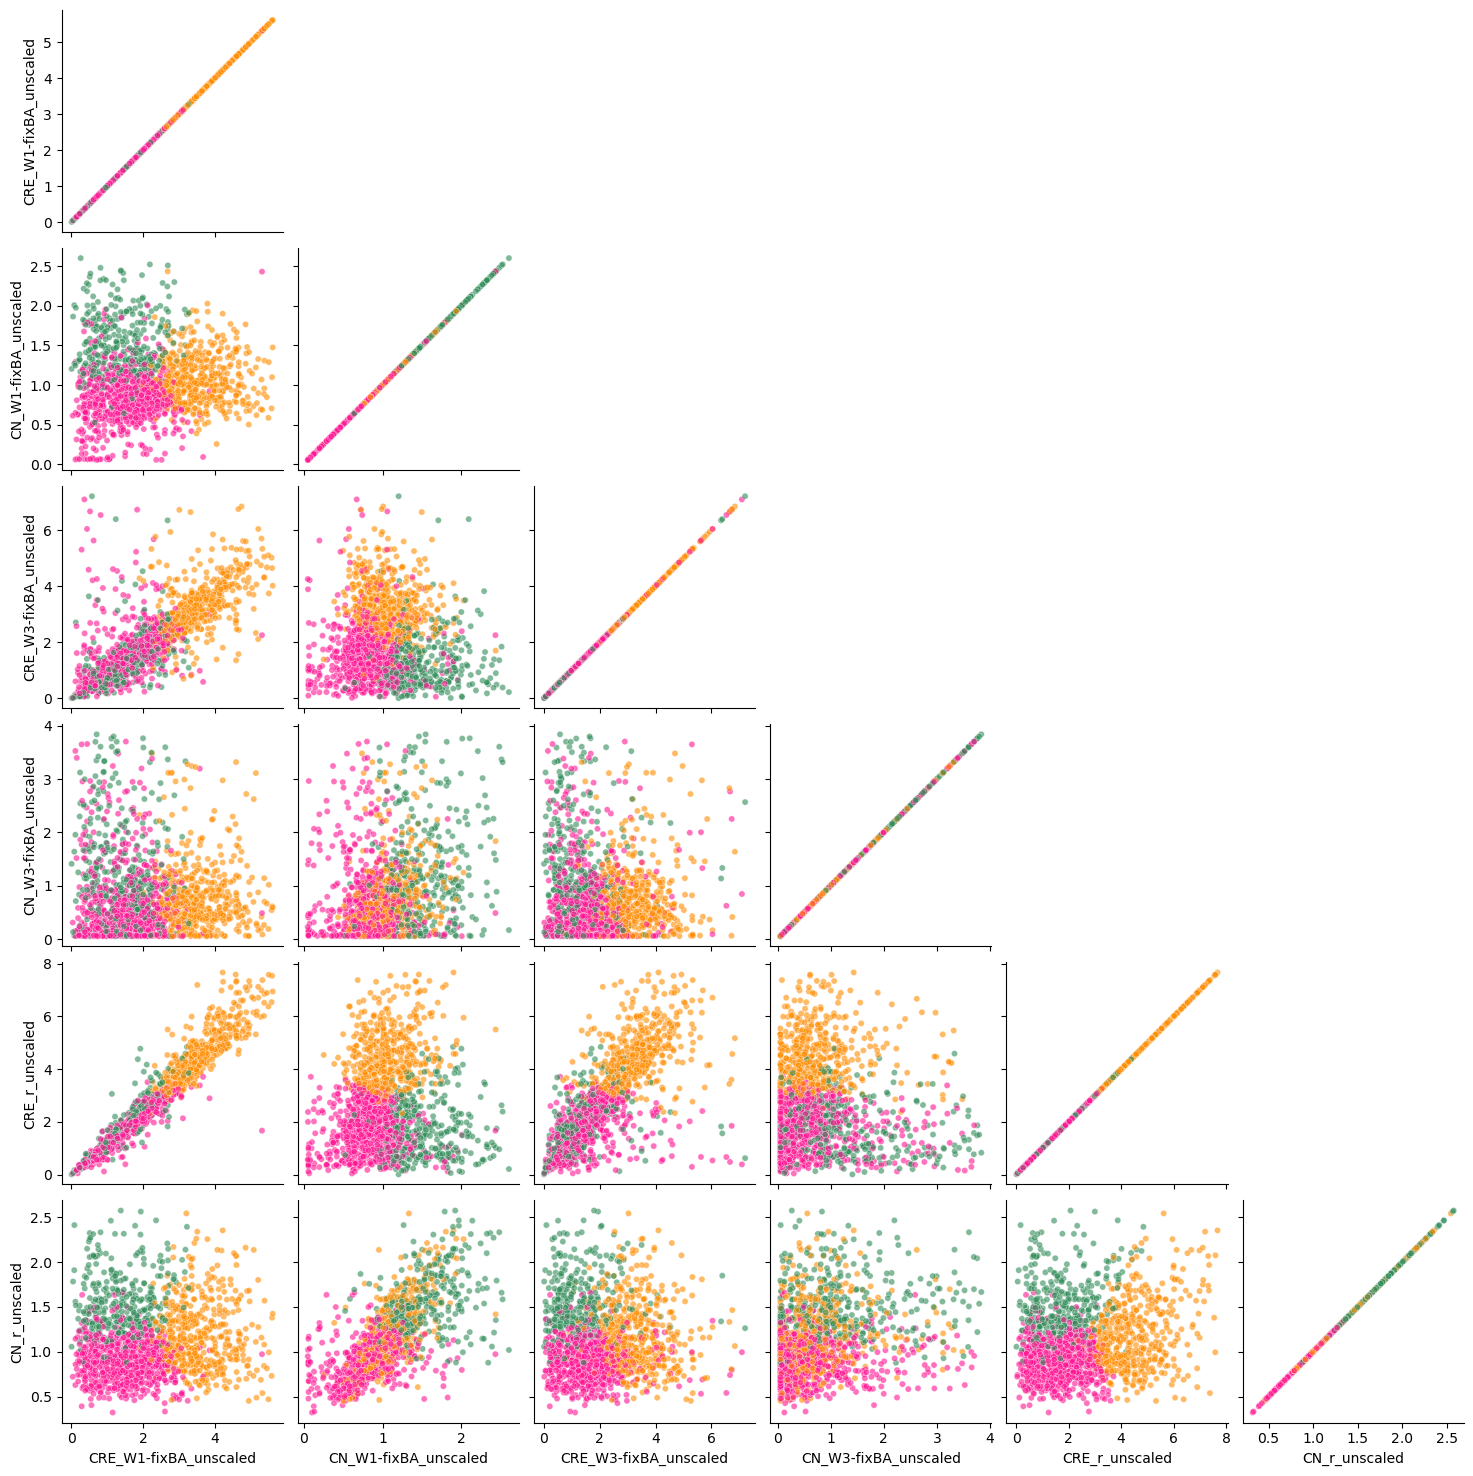

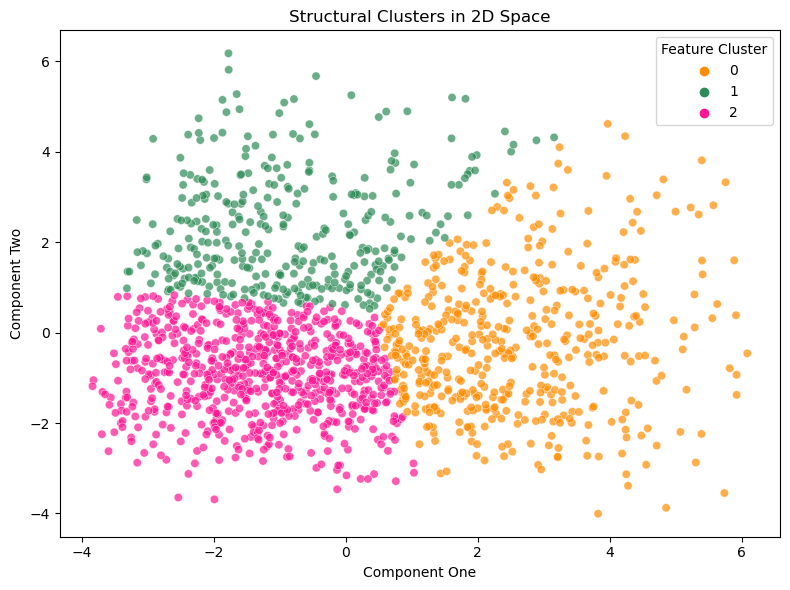

Environment 0 cluster 0: fraction 0.077+/-0.012
Environment 0 cluster 1: fraction 0.159+/-0.020
Environment 0 cluster 2: fraction 0.074+/-0.010
Environment 1 cluster 0: fraction 0.087+/-0.013
Environment 1 cluster 1: fraction 0.226+/-0.023
Environment 1 cluster 2: fraction 0.129+/-0.013
Environment 2 cluster 0: fraction 0.010+/-0.005
Environment 2 cluster 1: fraction 0.068+/-0.014
Environment 2 cluster 2: fraction 0.055+/-0.009
Environment 3 cluster 0: fraction 0.244+/-0.020
Environment 3 cluster 1: fraction 0.268+/-0.024
Environment 3 cluster 2: fraction 0.210+/-0.015
Environment 4 cluster 0: fraction 0.151+/-0.016
Environment 4 cluster 1: fraction 0.126+/-0.018
Environment 4 cluster 2: fraction 0.101+/-0.011
Environment 5 cluster 0: fraction 0.211+/-0.019
Environment 5 cluster 1: fraction 0.353+/-0.026
Environment 5 cluster 2: fraction 0.323+/-0.018
Environment 6 cluster 0: fraction 0.228+/-0.019
Environment 6 cluster 1: fraction 0.194+/-0.021
Environment 6 cluster 2: fraction 0.180+

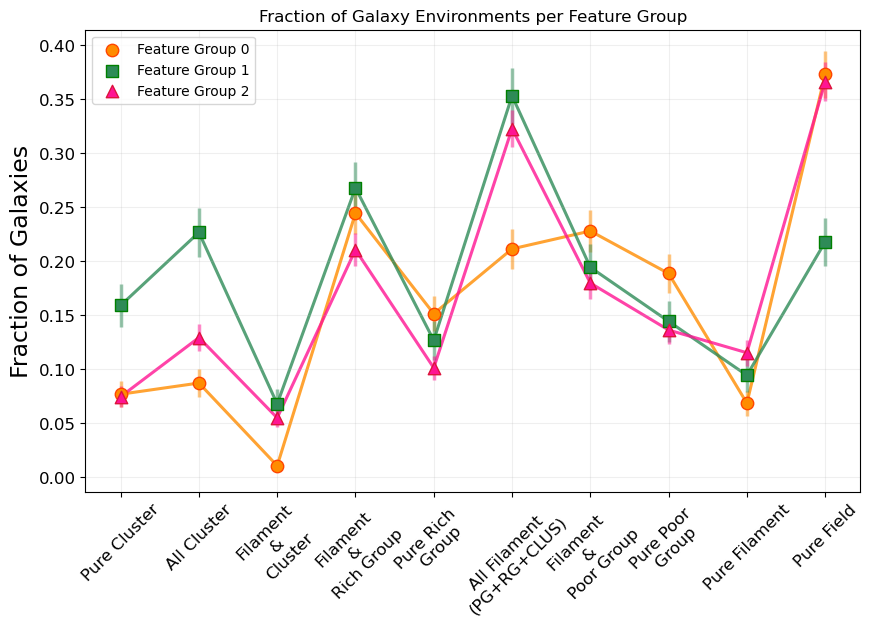

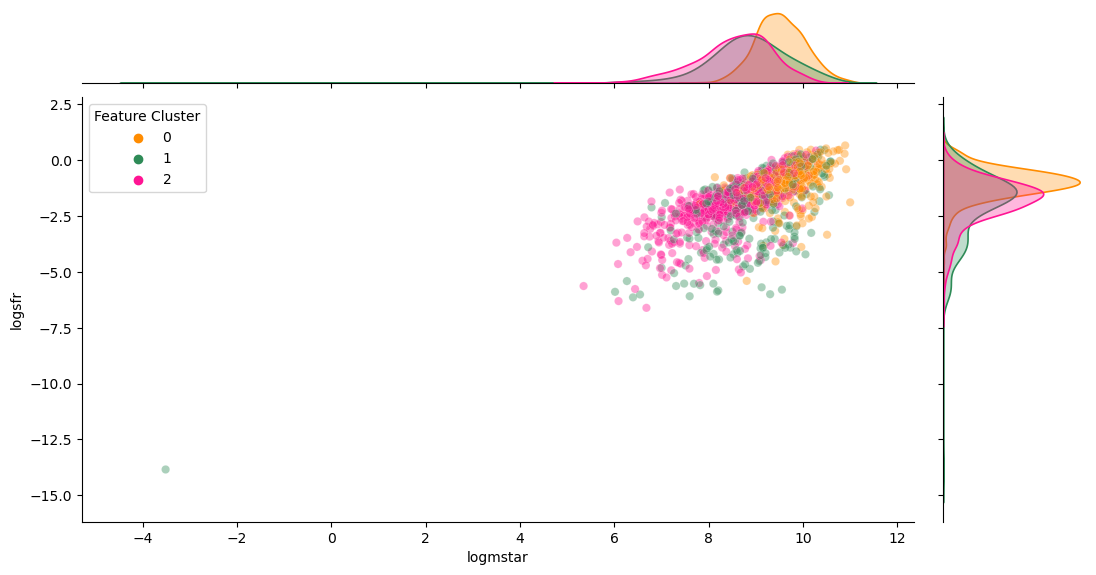

In [8]:
import warnings
warnings.filterwarnings("ignore")

df_scaled_colors = run_kmeans(colors=False)

(array([  9.,  31.,  71., 147., 184., 162., 135., 113.,  91.,  78.,  56.,
         37.,  41.,  28.,  27.,  12.,  18.,   8.,   7.,   8.]),
 array([0.2729 , 0.38535, 0.4978 , 0.61025, 0.7227 , 0.83515, 0.9476 ,
        1.06005, 1.1725 , 1.28495, 1.3974 , 1.50985, 1.6223 , 1.73475,
        1.8472 , 1.95965, 2.0721 , 2.18455, 2.297  , 2.40945, 2.5219 ]),
 <BarContainer object of 20 artists>)

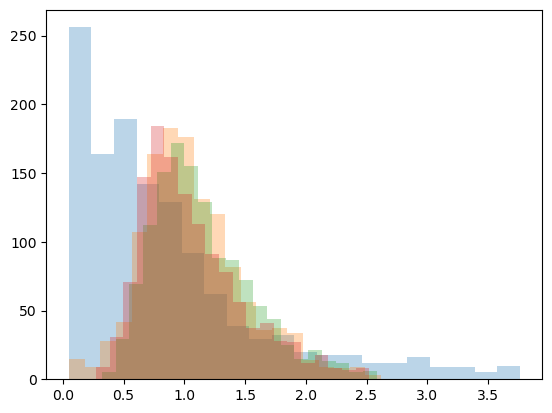

In [4]:
plt.hist(df_scaled_colors['CN_W3-fixBA_unscaled'],bins=20,alpha=0.3)
plt.hist(df_scaled_colors['CN_W1-fixBA_unscaled'],bins=20,alpha=0.3)
plt.hist(df_scaled_colors['CN_r_unscaled'],bins=20,alpha=0.3)
plt.hist(df_scaled_colors['CN_g_unscaled'],bins=20,alpha=0.3)

## HDBSCAN Run

In [1]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

Using average g and r effective radius!
Using average W1 and W2 effective radius!


USING THESE FEATURES: ['CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W2', 'CN_W3-fixBA', 'AVG_RE_gr', 
'AVG_RE_W1W2', 'NUV_r', 'W1_W3']

Reading feature data from data/feature_data.csv...

Either MIN_CLUSTER_SIZE or MIN_SAMPLE is set to None! Calculating optimal HDBSCAN parameters...

############################
 Best parameters at elbow:
   min_cluster_size         = 20
   min_samples              = 10
   metric                   = canberra
   cluster_selection_method = leaf
   total stability          = 0.430
############################


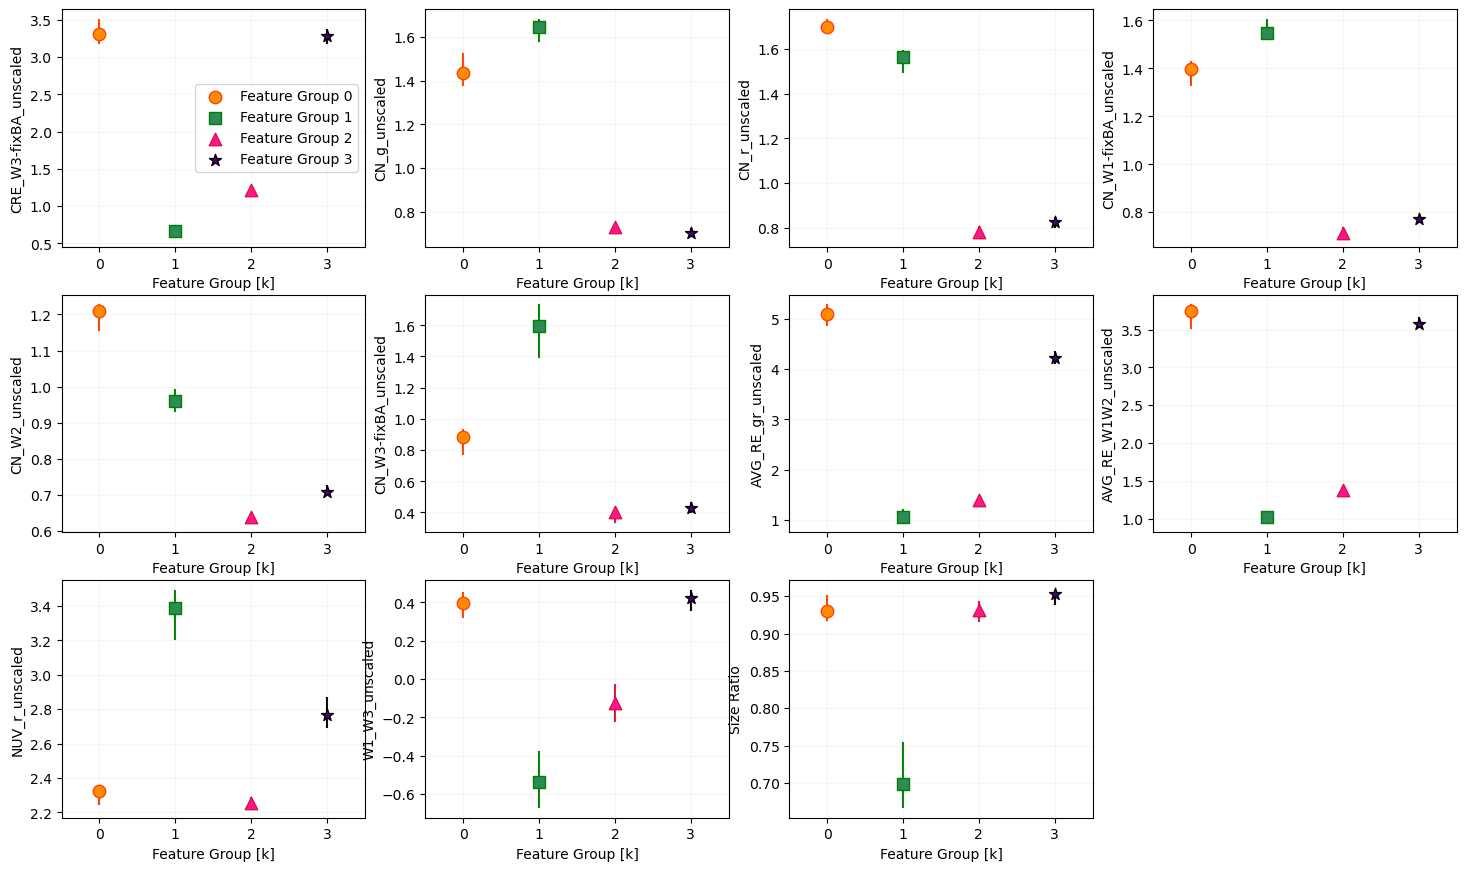

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/hdbscan_features.csv:

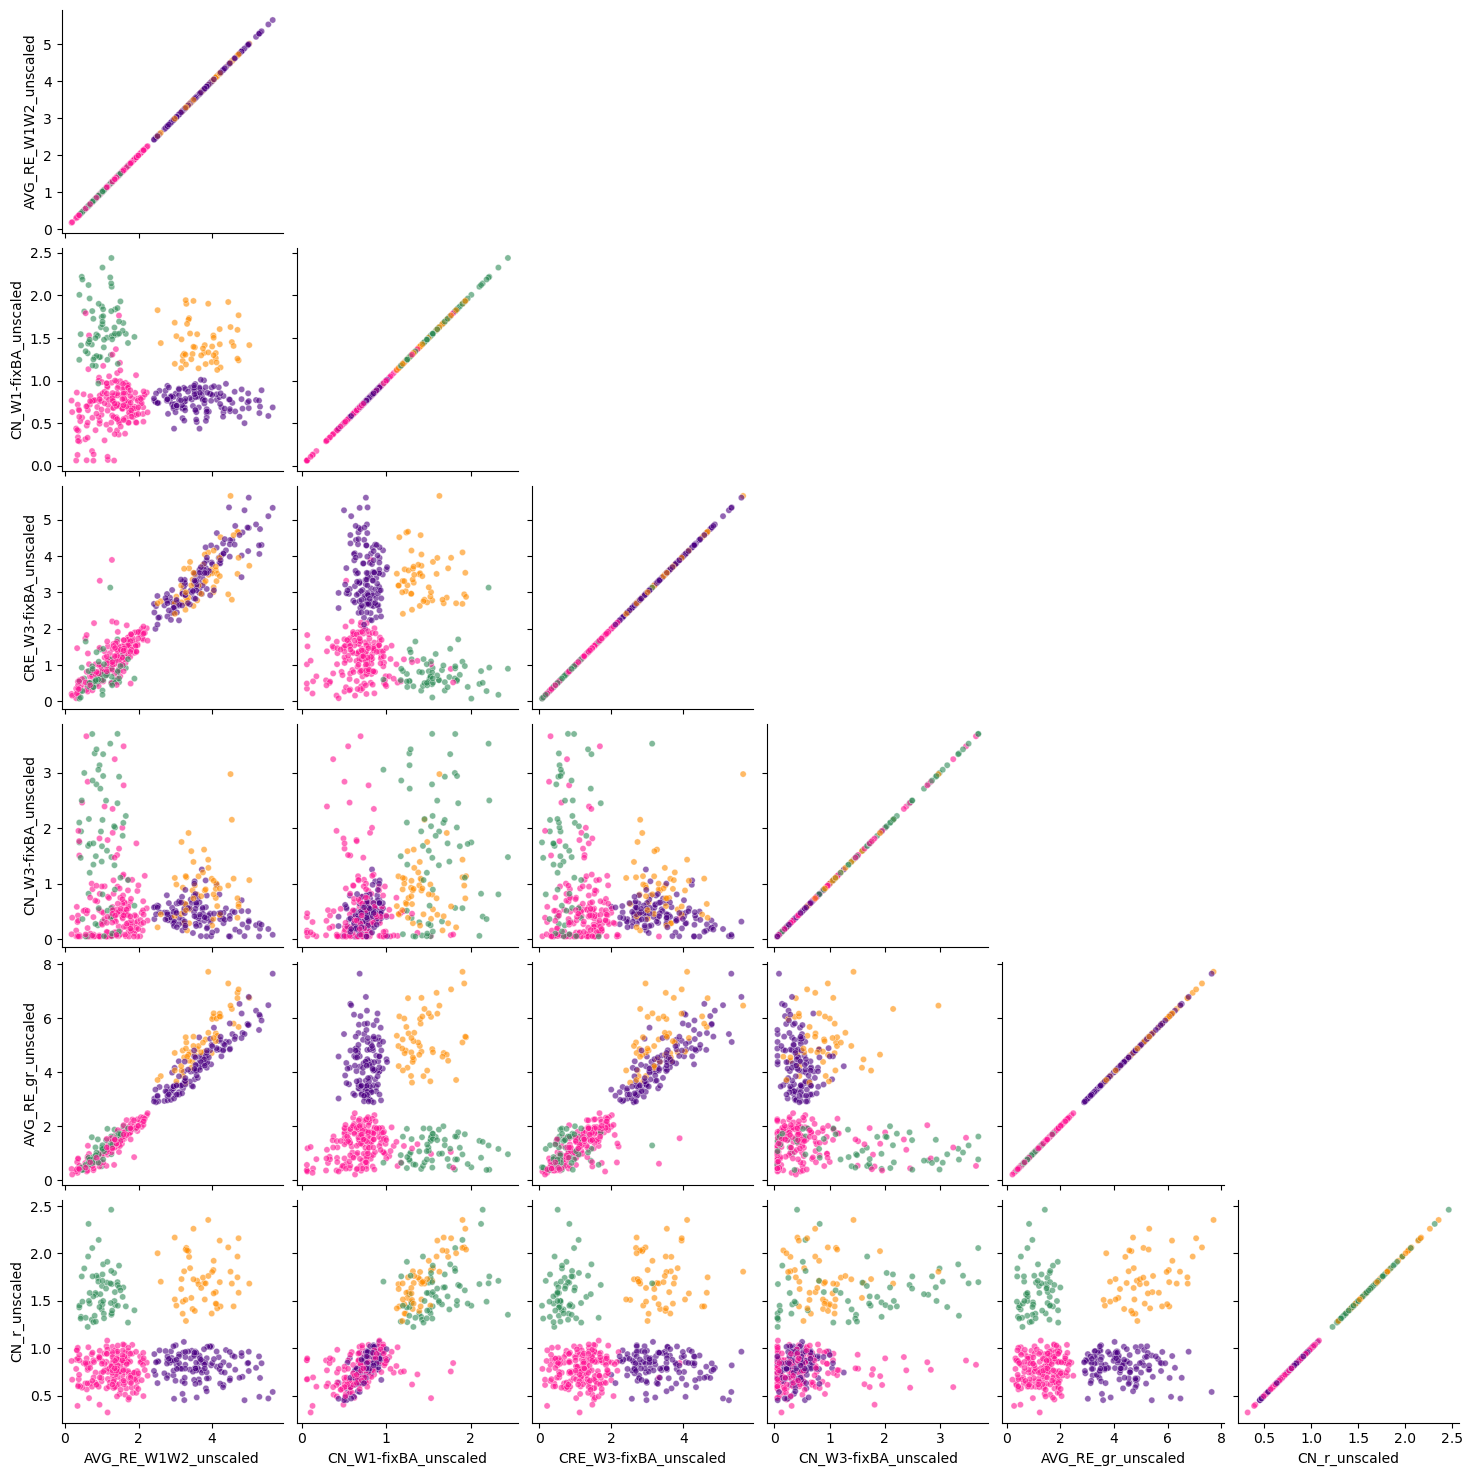

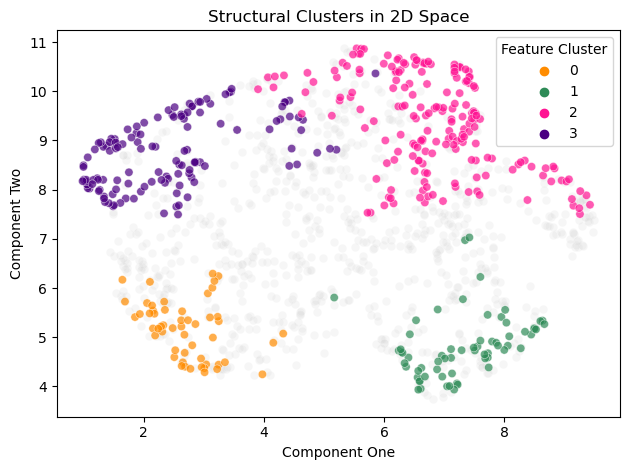

Environment 0 cluster -1: fraction 0.098+/-0.010
Environment 0 cluster 0: fraction 0.038+/-0.026
Environment 0 cluster 1: fraction 0.185+/-0.048
Environment 0 cluster 2: fraction 0.048+/-0.015
Environment 0 cluster 3: fraction 0.069+/-0.022
Environment 1 cluster -1: fraction 0.137+/-0.012
Environment 1 cluster 0: fraction 0.057+/-0.032
Environment 1 cluster 1: fraction 0.262+/-0.055
Environment 1 cluster 2: fraction 0.106+/-0.022
Environment 1 cluster 3: fraction 0.077+/-0.023
Environment 2 cluster -1: fraction 0.039+/-0.007
Environment 2 cluster 0: fraction 0.019+/-0.019
Environment 2 cluster 1: fraction 0.077+/-0.033
Environment 2 cluster 2: fraction 0.058+/-0.017
Environment 2 cluster 3: fraction 0.008+/-0.008
Environment 3 cluster -1: fraction 0.266+/-0.015
Environment 3 cluster 0: fraction 0.321+/-0.064
Environment 3 cluster 1: fraction 0.292+/-0.056
Environment 3 cluster 2: fraction 0.175+/-0.028
Environment 3 cluster 3: fraction 0.231+/-0.037
Environment 4 cluster -1: fraction 0

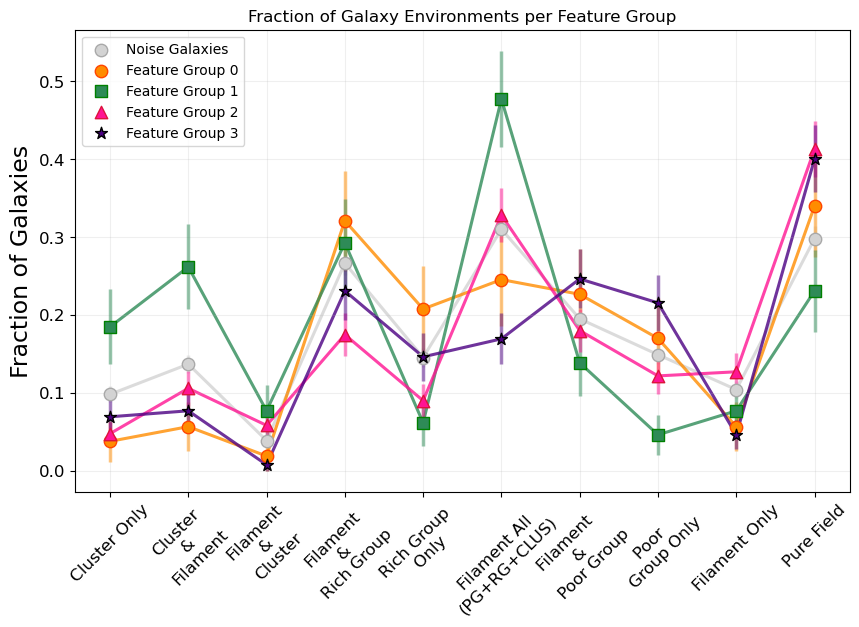

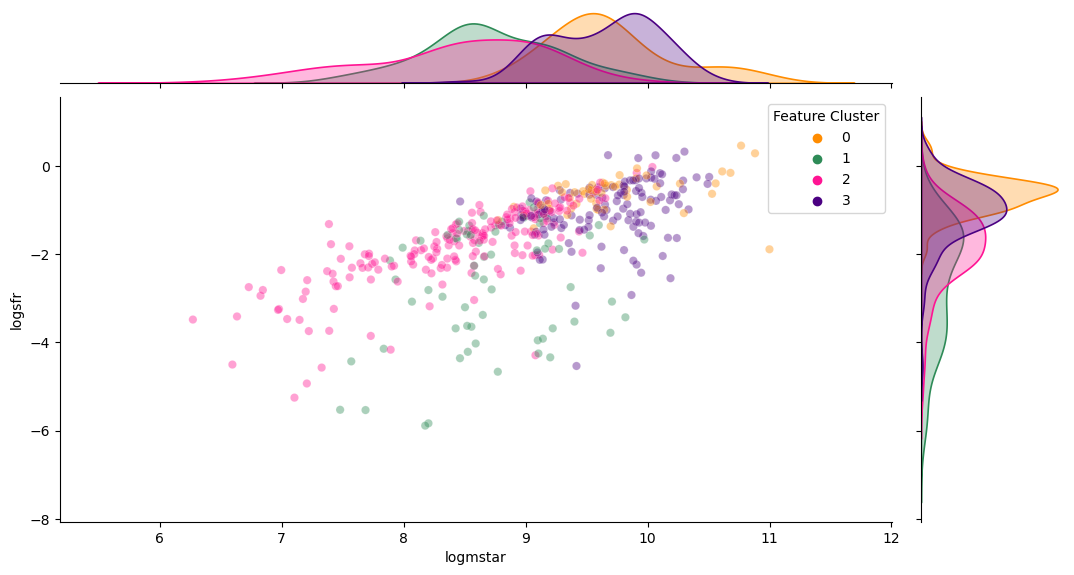

In [2]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan(colors=True, flux=False)

## Testbed

In [105]:
import sys
sys.path.insert(0,'utils')
from clustering_utils import run1_hdbscan, umap_2d, find_optimal_hdbparams
from plotting_utils import plot_clusters, plot_corner, plot_env_fraction

import warnings
warnings.filterwarnings("ignore")

In [106]:
import pandas as pd
df_scaled = pd.read_csv('data/feature_data.csv')
features=['CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W2', 'CN_W3-fixBA', 'AVG_RE_gr', 
'AVG_RE_W1W2', 'NUV_r', 'W1_W3']

In [3]:
%load_ext autoreload
%autoreload 2

In [107]:
best=find_optimal_hdbparams(df_scaled, features)

HDBSCAN hyperparameter sweep:   0%|          | 0/240 [00:00<?, ?it/s]

############################
 Best parameters at elbow:
   min_cluster_size         = 20
   min_samples              = 10
   metric                   = canberra
   cluster_selection_method = leaf
   total stability          = 0.430
############################


In [108]:
min_cluster_size = best[0]
min_samples = best[1]
metric = best[2]
cluster_selection_method = best[3]

In [109]:
#perform HDBSCAN on the full set of features, using the parameters defined above.
feature_data = run1_hdbscan(df_scaled, features, min_cluster_size=min_cluster_size, min_samples=min_samples,
                           metric=metric, cluster_selection_method=cluster_selection_method)

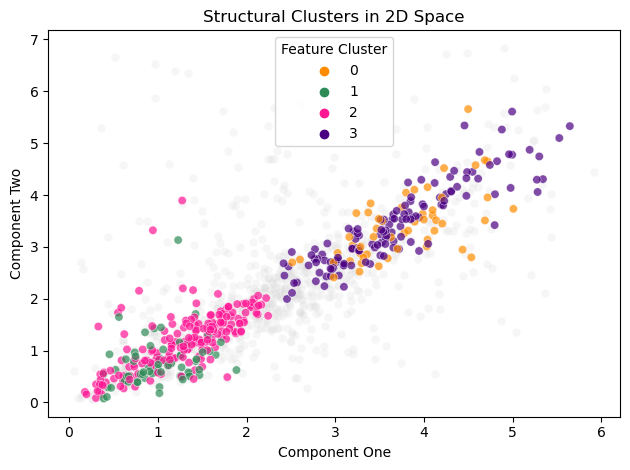

In [111]:
#create the Comp1, Comp2 columns. IGNORES 'Feature Cluster' column!
feature_data_umap = umap_2d(feature_data, features)

#plort.
plot_clusters(feature_data_umap, x='AVG_RE_W1W2_unscaled', y='CRE_W3-fixBA_unscaled')

In [112]:
df_scaled.columns

Index(['CXC_g', 'CRE_g', 'CN_g', 'CNumerical_Error_g', 'CXC_r', 'CRE_r',
       'CN_r', 'CNumerical_Error_r', 'CXC_W1-fixBA', 'CRE_W1-fixBA',
       'CN_W1-fixBA', 'CNumerical_Error_W1-fixBA', 'CXC_W2', 'CRE_W2', 'CN_W2',
       'CNumerical_Error_W2', 'CXC_W3-fixBA', 'CRE_W3-fixBA', 'CN_W3-fixBA',
       'CNumerical_Error_W3-fixBA', 'Vcosmic', 'logmstar', 'logsfr',
       'Size Ratio', 'NUV_r', 'W1_W3', 'cluster_member', 'rich_group_memb',
       'poor_group_memb', 'filament_member', 'pure_field', 'AVG_RE_gr',
       'AVG_RE_W1W2', 'CRE_W3-fixBA_unscaled', 'CN_g_unscaled',
       'CN_r_unscaled', 'CN_W1-fixBA_unscaled', 'CN_W2_unscaled',
       'CN_W3-fixBA_unscaled', 'AVG_RE_gr_unscaled', 'AVG_RE_W1W2_unscaled',
       'NUV_r_unscaled', 'W1_W3_unscaled'],
      dtype='object')

Environment 0 cluster -1: fraction 0.137+/-0.012
Environment 0 cluster 0: fraction 0.057+/-0.032
Environment 0 cluster 1: fraction 0.262+/-0.055
Environment 0 cluster 2: fraction 0.106+/-0.022
Environment 0 cluster 3: fraction 0.077+/-0.023
Environment 1 cluster -1: fraction 0.266+/-0.015
Environment 1 cluster 0: fraction 0.321+/-0.064
Environment 1 cluster 1: fraction 0.292+/-0.056
Environment 1 cluster 2: fraction 0.175+/-0.028
Environment 1 cluster 3: fraction 0.231+/-0.037
Environment 2 cluster -1: fraction 0.195+/-0.014
Environment 2 cluster 0: fraction 0.226+/-0.057
Environment 2 cluster 1: fraction 0.138+/-0.043
Environment 2 cluster 2: fraction 0.180+/-0.028
Environment 2 cluster 3: fraction 0.246+/-0.038
Environment 3 cluster -1: fraction 0.310+/-0.016
Environment 3 cluster 0: fraction 0.245+/-0.059
Environment 3 cluster 1: fraction 0.477+/-0.062
Environment 3 cluster 2: fraction 0.328+/-0.034
Environment 3 cluster 3: fraction 0.169+/-0.033
Environment 4 cluster -1: fraction 0

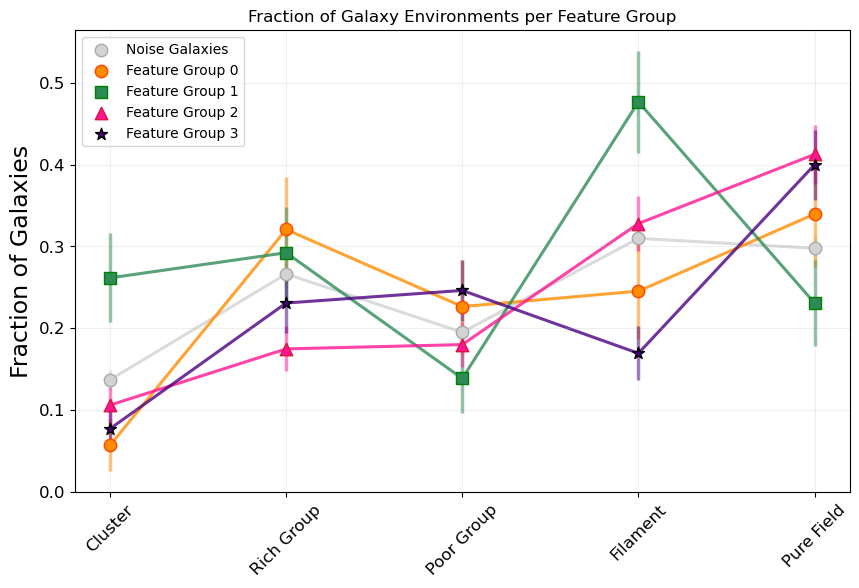

In [113]:
plot_env_fraction(feature_data, main_only=True)